# EDA (Exploratory Data Analisys)

Esta seccion se enfocara en responder la preguntas que se han planteado al principio de este proyecto

1. ¿Cuáles cursos generan más ingresos?
2. ¿Qué perfil de cliente compra más?
3. ¿Qué responsables comerciales venden mejor?
4. ¿Cómo evolucionan las ventas en el tiempo?
5. ¿Qué variables parecen influir más en las ventas?

In [44]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from OOP_visualizations import Graph

In [45]:
sns.set_theme(style='darkgrid', palette='deep', font_scale=1.1)

In [46]:
# Import data

df_fv = pd.read_excel('./data_source/data_query_for_fac_ventas.xlsx')

In [47]:
df_fv.info()

<class 'pandas.DataFrame'>
RangeIndex: 7701 entries, 0 to 7700
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   NUMERO_DE_IDENTIFICACION  7701 non-null   int64         
 1   PRIMER_APELLIDO           7701 non-null   str           
 2   SEGUNDO_APELLIDO          7701 non-null   str           
 3   PRIMER_NOMBRE             7701 non-null   str           
 4   SEGUNDO_NOMBRE            7701 non-null   str           
 5   CURSO                     7701 non-null   str           
 6   PRECIO_NETO               7701 non-null   float64       
 7   FECHA_DE_PAGO             7701 non-null   datetime64[us]
 8   RENOVACION                7701 non-null   str           
 9   FECHA_DE_VENTA            7701 non-null   datetime64[us]
 10  PROFESION                 7701 non-null   str           
 11  GENERO                    7701 non-null   str           
 12  FECHA_DE_NACIMIENTO       5223 

In [48]:
df_fv.columns.to_list()

['NUMERO_DE_IDENTIFICACION',
 'PRIMER_APELLIDO',
 'SEGUNDO_APELLIDO',
 'PRIMER_NOMBRE',
 'SEGUNDO_NOMBRE',
 'CURSO',
 'PRECIO_NETO',
 'FECHA_DE_PAGO',
 'RENOVACION',
 'FECHA_DE_VENTA',
 'PROFESION',
 'GENERO',
 'FECHA_DE_NACIMIENTO',
 'CIUDAD_REGION',
 'MODALIDAD',
 'PROCEDENCIA',
 'MEDIO_DE_PAGO',
 'RESPONSABLE_VENTA',
 'ELABORO',
 'EDAD',
 'ANIO_VENTA',
 'MES_VENTA',
 'GRUPO_EDAD']

## 1. ¿Cuales cursos generan mas ingresos?

In [49]:
# How many courses CSS had taught?

len(df_fv['CURSO'].unique())

62

In [50]:
resumen_cursos = df_fv.groupby('CURSO').agg(
    total_estudiantes = ('NUMERO_DE_IDENTIFICACION', 'count'),
    total_ventas = ('PRECIO_NETO', 'sum')

).round(2).reset_index().sort_values(by=['total_ventas'], ascending=False).head(5)

resumen_cursos


,CURSO,total_estudiantes,total_ventas
61,Violencia sexual,1146,33402714.97
0,Acls,323,29765760.00
9,Bls,888,26191001.97
27,Humanización,863,25476834.97
47,Químicos,749,22000269.97


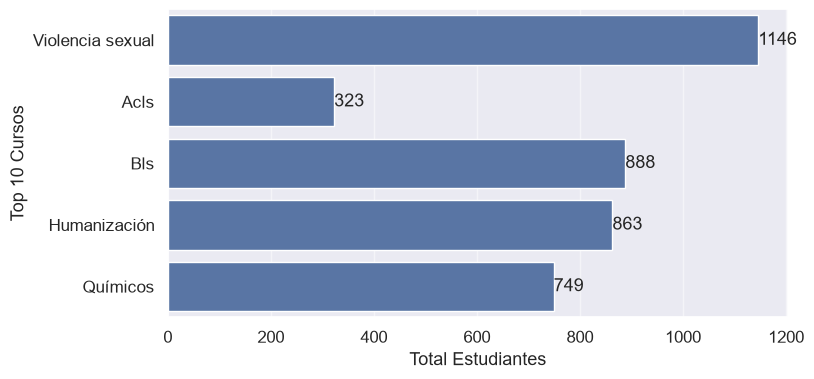

In [51]:
# Show students quantity by course, showing top 10

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=resumen_cursos,
    x = 'total_estudiantes',
    y = 'CURSO'
)


for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.xlabel('Total Estudiantes')
plt.xticks(rotation=0)

plt.ylabel('Top 10 Cursos')

plt.show()

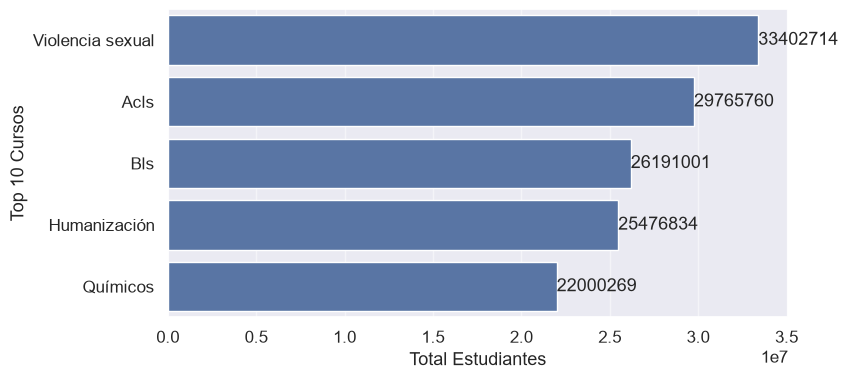

In [52]:
# Show students quantity by course, showing top 10

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=resumen_cursos,
    x = 'total_ventas',
    y = 'CURSO'
)


for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.xlabel('Total Estudiantes')
plt.xticks(rotation=0)

plt.ylabel('Top 10 Cursos')

plt.show()

In [53]:
resumen_cursos_tiempo = df_fv.groupby(['ANIO_VENTA','CURSO']).agg(
    total_estudiantes = ('NUMERO_DE_IDENTIFICACION', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_ventas = ('PRECIO_NETO', 'sum')

).round(2).reset_index().sort_values(by=['ANIO_VENTA','total_ventas'], ascending=False)

resumen_cursos_tiempo

,ANIO_VENTA,CURSO,total_estudiantes,ticket_promedio,total_ventas
102,2026,Humanización,318,29366.25,9338466.64
127,2026,Violencia sexual,276,27155.68,7494966.64
115,2026,Primeros auxilios,137,43563.50,5968200.00
117,2026,Químicos,202,27366.17,5527966.64
100,2026,Duelo,178,26986.89,4803666.64
...,...,...,...,...,...
3,2024,Adulto mayor,1,35000.00,35000.00
11,2024,Dea,2,15000.00,30000.00
12,2024,Discapacidad,1,25000.00,25000.00
20,2024,Liderazgo,1,0.00,0.00


#### ¿Que cursos generan mas ingresos?

Con el anterior estudio se puede afirmar que los cursos que mas ingresos han representado para CC entre el periodo de 2024 a 2026 son:

1.  Violencia sexual con 1146 estudiantes y un total vendido de: 33,402,714.97
2.	Acls con 323 estudiantes y un total vendido de: 29,765,760.00
3.	Bls	con 888 estudiantes y un total vendido de: 26,191,001.97
4.	Humanización con 863 estudiantes y un total vendido de: 25,476,834.97
5.	Químicos con 748 estudiantes y un total vendido de: 21,920,269.97

Los cursos mas consistentes en ventas en estos tres periodos 2024,2025 y 2026 son

1. Violencia sexual
2. Quimicos

Se observa que el curso de ACLS es el que con menor numero de ventas mayor cantidad de ingresos genera al tener un ticket promedio de venta mas alto en un promedio de $94,000 COP


## 2. ¿Que perfil de cliente compra mas?

In [54]:
# How many studenst betwen 2024 and 2026 CCS has?

len(df_fv['NUMERO_DE_IDENTIFICACION'].unique())

2920

In [55]:
# Leaving unique students on DB
df_fv_clientes = df_fv.drop_duplicates(subset=['NUMERO_DE_IDENTIFICACION'], keep='last')

In [56]:
len(df_fv_clientes['NUMERO_DE_IDENTIFICACION'])

2920

In [57]:
# Percentage of unknown registers on 'GENERO' column

(df_fv.loc[df_fv['GENERO'] == 'UNKNOWN']['NUMERO_DE_IDENTIFICACION'].count() * 100) / df_fv['NUMERO_DE_IDENTIFICACION'].count()


np.float64(24.646149850668746)

In [58]:
#

df_fv_clientes['GENERO'].value_counts()

GENERO
Femenino     1497
UNKNOWN       854
Masculino     569
Name: count, dtype: int64

<Axes: xlabel='EDAD', ylabel='Density'>

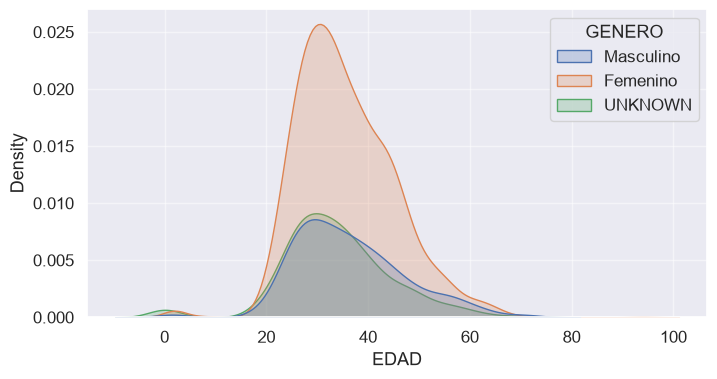

In [59]:
plt.figure(figsize=(8,4))
sns.kdeplot(
    data=df_fv_clientes,
    x='EDAD',
    hue='GENERO',
    fill=True
)

In [60]:
df_fv_clientes['GRUPO_EDAD'].value_counts()

GRUPO_EDAD
Adulto    1172
Joven      700
Senior     167
Menor       15
Name: count, dtype: int64

In [61]:
resumen_clientes = df_fv_clientes.groupby(['GRUPO_EDAD', 'GENERO']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

resumen_clientes

,GRUPO_EDAD,GENERO,numero_estudiantes,ticket_promedio,total_vendido
0,Adulto,Femenino,695,35960.621583,24992632.00
1,Adulto,Masculino,247,36528.627530,9022571.00
2,Adulto,UNKNOWN,230,27382.608696,6298000.00
3,Joven,Femenino,394,37720.726726,14861966.33
4,Joven,Masculino,145,37308.275862,5409700.00
5,Joven,UNKNOWN,161,39571.428571,6371000.00
6,Menor,Femenino,9,38955.555556,350600.00
7,Menor,Masculino,4,23750.000000,95000.00
8,Menor,UNKNOWN,2,45250.000000,90500.00
9,Senior,Femenino,90,34033.333333,3063000.00


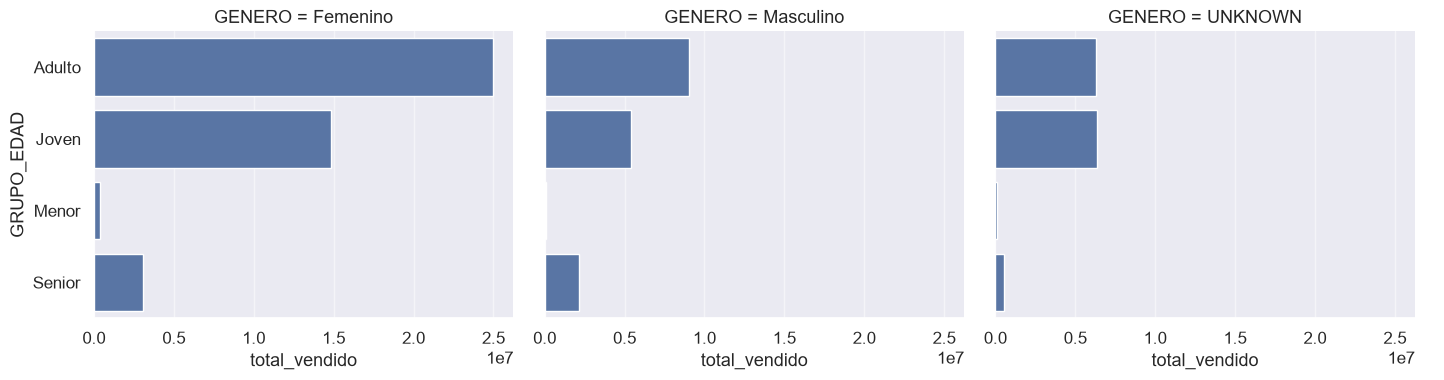

In [62]:
g = sns.catplot(
    data=resumen_clientes,
    x='total_vendido',
    y='GRUPO_EDAD',
    col='GENERO',
    kind='bar',
    height=4,
    aspect=1.2
)

In [63]:
resumen_clientes_region = df_fv_clientes.groupby(['CIUDAD_REGION', 'GENERO']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

resumen_clientes_region

,CIUDAD_REGION,GENERO,numero_estudiantes,ticket_promedio,total_vendido
0,Pasto - Nariño,Femenino,1496,34627.553697,51802820.33
1,Pasto - Nariño,Masculino,569,34872.282953,19842329.00
2,Pasto - Nariño,UNKNOWN,685,26952.310423,18462332.64
3,Tumaco - Nariño,UNKNOWN,74,0.000000,0.00
4,UNKNOWN,Femenino,1,30000.000000,30000.00
5,UNKNOWN,UNKNOWN,95,38526.315789,3660000.00


In [64]:
resumen_clientes_procedencia = df_fv_clientes.groupby(['PROCEDENCIA', 'GENERO']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['numero_estudiantes', 'total_vendido'], ascending=False)

resumen_clientes_procedencia

,PROCEDENCIA,GENERO,numero_estudiantes,ticket_promedio,total_vendido
6,Facebook,Femenino,1332,34915.781029,46507820.33
7,Facebook,Masculino,519,35213.543353,18275829.00
2,Alianzas comerciales,UNKNOWN,357,23955.648852,8552166.64
8,Facebook,UNKNOWN,265,16851.569811,4465666.00
17,UNKNOWN,UNKNOWN,147,39812.925170,5852500.00
0,Alianzas comerciales,Femenino,63,28698.412698,1808000.00
15,UNKNOWN,Femenino,58,34396.551724,1995000.00
5,Cliente antiguo,UNKNOWN,36,29722.222222,1070000.00
11,Recomendación de compañero,UNKNOWN,28,42000.000000,1176000.00
3,Cliente antiguo,Femenino,28,34071.428571,954000.00


In [65]:
resumen_clientes_mediodepago = df_fv_clientes.groupby(['MEDIO_DE_PAGO', 'GRUPO_EDAD']).agg(
    numero_estudiantes = ('GENERO', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['numero_estudiantes', 'ticket_promedio', 'total_vendido'], ascending=False)

resumen_clientes_mediodepago

,MEDIO_DE_PAGO,GRUPO_EDAD,numero_estudiantes,ticket_promedio,total_vendido
23,Nequi,Adulto,535,37699.685981,20169332.00
24,Nequi,Joven,321,41368.638629,13279333.00
2,Bancolombia,Adulto,164,35399.823171,5805571.00
40,Transferencia Bancaria Bancolombia,Adulto,130,31884.615385,4145000.00
44,UNKNOWN,Adulto,114,10333.333333,1178000.00
3,Bancolombia,Joven,100,34730.000000,3473000.00
41,Transferencia Bancaria Bancolombia,Joven,91,35131.868132,3197000.00
26,Nequi,Senior,83,35834.939759,2974300.00
15,Daviplata,Adulto,82,41003.658537,3362300.00
7,Caja,Adulto,80,47475.000000,3798000.00


#### ¿Que perfil de cliente compra mas?

Con el anterior estudio se puede afirmar que el perfil de cleinte que mas a generado ingresos para CCS entre el periodo de 2024 a 2026 es:

1. Un perfil femenino entre los 30 y 50 años, principalmente ubicado en Pasto, principal mente ha llegado a CCS por medio de facebook y su metodo de pago preferencial es NEQUI o BANCOLOMBIA

## ¿Qué responsables comerciales venden mejor?

In [66]:
resumen_vendedor = df_fv.groupby(['RESPONSABLE_VENTA']).agg(
    total_ventas = ('NUMERO_DE_IDENTIFICACION', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['total_ventas'], ascending=False).head(6)

resumen_vendedor

,RESPONSABLE_VENTA,total_ventas,ticket_promedio,total_vendido
3,Ccs,3708,37046.003501,1.373666e+08
27,Proinsalud,1250,25706.400000,3.213300e+07
33,Yurani Daniela Goyes Mora,979,29239.632278,2.862560e+07
17,Lucio Francisco Rosero Muñoz,395,21302.104177,8.414331e+06
14,Ipiales,344,26613.372093,9.155000e+06
18,Luis Olivares Pinta Lopez,195,29923.066667,5.834998e+06


In [67]:
resumen_vendedor = df_fv.groupby(['ANIO_VENTA','RESPONSABLE_VENTA']).agg(
    total_ventas = ('NUMERO_DE_IDENTIFICACION', 'count'),
    ticket_promedio = ('PRECIO_NETO', 'mean'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=['ANIO_VENTA','total_ventas'], ascending=(True,False))

resumen_vendedor

,ANIO_VENTA,RESPONSABLE_VENTA,total_ventas,ticket_promedio,total_vendido
3,2024,Ccs,835,42787.056287,35727192.00
27,2024,Yurani Daniela Goyes Mora,451,29932.594235,13499600.00
16,2024,Luis Olivares Pinta Lopez,120,28816.650000,3457998.00
15,2024,Lucio Francisco Rosero Muñoz,116,20698.258621,2400998.00
11,2024,H. Divino Niño,84,32142.904762,2700004.00
23,2024,Proinsalud,76,25921.052632,1970000.00
12,2024,H. San Pedro,67,39805.970149,2667000.00
8,2024,Fatima,52,20000.000000,1040000.00
2,2024,Brayan,51,37059.156863,1890017.00
17,2024,Marcela Pinzon,40,1875.000000,75000.00


#### ¿Qué responsables comerciales venden mejor?

Con el anterior estudio se puede afirmar que el perfil de vendedor  que mas ha generado ingresos para CCS entre el periodo de 2024 a 2026 es:

1. Yurani Daniela Goyes Mora con 925 ventas
2. Lucio Francisco Rosero Muñoz con 395 ventas
3. Luis Olivares Pinta Lopez con 195 ventas



# 4. ¿Cómo evolucionan las ventas en el tiempo?

In [68]:
resumen_ventas_tiempo = df_fv.groupby(['ANIO_VENTA', 'MES_VENTA']).agg(
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

resumen_ventas_tiempo

,ANIO_VENTA,MES_VENTA,total_vendido
0,2024,Abril,10620298.00
1,2024,Agosto,5936999.00
2,2024,Diciembre,4426000.00
3,2024,Febrero,6260016.00
4,2024,Julio,8594000.00
5,2024,Junio,5837900.00
6,2024,Marzo,5520604.00
7,2024,Mayo,5295000.00
8,2024,Noviembre,8112999.00
9,2024,Octubre,4360000.00


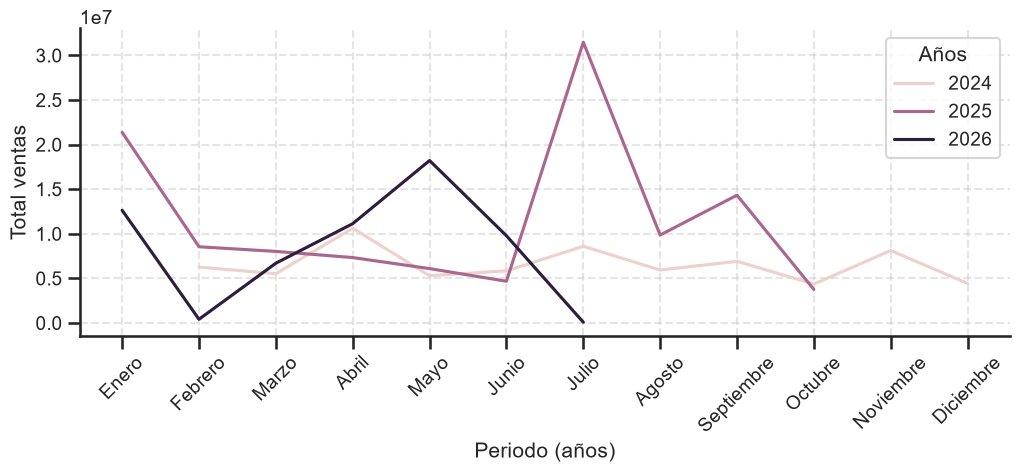

In [69]:
plt.figure(figsize=(12,4))

# Define month order
orden_meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
               "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

# Convert object column to categorical column and order the categories
resumen_ventas_tiempo["MES_VENTA"] = pd.Categorical(
    resumen_ventas_tiempo["MES_VENTA"],
    categories=orden_meses,
    ordered=True
)


style = {
"axes.spines.top": False,
"axes.spines.right": False,
"axes.grid": True,
"grid.linestyle": "--",
"grid.alpha": 0.5,
"font.family": "sans-serif"
}

sns.set_theme(style="ticks", rc=style)
sns.set_context("talk", font_scale=0.85)

palette_premium = ["#1e3a8a", "#0d9488", "#e11d48", "#64748b"]
sns.set_palette(sns.color_palette(palette_premium))

sns.lineplot(
    data=resumen_ventas_tiempo,
    x='MES_VENTA',
    y='total_vendido',
    hue='ANIO_VENTA'
)

plt.xlabel('Periodo (años)')
plt.legend(title='Años')
plt.ylabel('Total ventas')

plt.xticks(rotation=45)
plt.show()

In [70]:
resumen_ventas_tiempo2 = df_fv.groupby(['ANIO_VENTA']).agg(
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

resumen_ventas_tiempo2

,ANIO_VENTA,total_vendido
0,2024,7.186781e+07
1,2025,1.154355e+08
2,2026,5.893073e+07


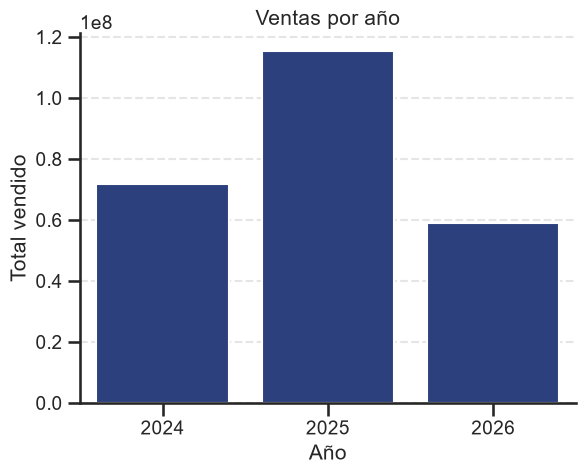

In [71]:
sns.barplot(
    data=resumen_ventas_tiempo2,
    x='ANIO_VENTA',
    y='total_vendido'
)

plt.title('Ventas por año')
plt.xlabel('Año')
plt.ylabel('Total vendido')

plt.show()

#### ¿Cómo evolucionan las ventas en el tiempo?

Con el anterior estudio se puede afirmar que las ventas en los periodos 2024, 2025 y 2026 tienen una clara tendecia al alza, donde se puede ver segun la grafica de tiempo que los meses que mayor ventas se presentas es en Enero, Mayo, Julio. Adicional a eso se puede afirmar que la tendecioa de ingresos va creciendo ya que el 2025 el total vendido supero a año anterior 2024 y a julio de 2026 las ventas ya estan cerca de igualar a las ventas totales del año 2024.

# 5. ¿Qué variables parecen influir más en las ventas?

In [72]:
df_fv['RESPONSABLE_VENTA'].unique()

<StringArray>
['Lucio Francisco Rosero Muñoz',                     'Provired',
        'Nicolas Rosero Patiño',                          'Ccs',
                       'Brayan',                  'Divino Niño',
    'Luis Olivares Pinta Lopez',    'Yurani Daniela Goyes Mora',
                   'Corposalud',                       'Fatima',
                       'Avanti',                 'H. San Pedro',
                 'Chino Tumaco',                      'UNKNOWN',
                        'Paola',   'Lina Maria Guerrero Patiño',
                   'Proinsalud',                   'Formedical',
                  'Pasto Salud',               'Marcela Pinzon',
                     'Hosdenar',              'Espacio Publico',
      'Sebastian Rosero Patiño',               'H. Divino Niño',
                         'Maya',                        'Peñol',
                     'Fundonar',                  'Apolo´S Gym',
                      'Ipiales',               'Palermo Imagen',
           

In [73]:
vendedores = [
    "Lucio Francisco Rosero Muñoz",
    "Nicolas Rosero Patiño",
    "Brayan",
    "Luis Olivares Pinta Lopez",
    "Yurani Daniela Goyes Mora",
    "Paola",
    "Lina Maria Guerrero Patiño",
    "Marcela Pinzon",
    "Sebastian Rosero Patiño",
    "Maya",
    "Juan Camilo Urbano Paredes"
]

contratos = [
    "Provired",
    "Divino Niño",
    "Corposalud",
    "Fatima",
    "Avanti",
    "H. San Pedro",
    "Chino Tumaco",
    "UNKNOWN",
    "Proinsalud",
    "Formedical",
    "Pasto Salud",
    "Hosdenar",
    "Espacio Publico",
    "H. Divino Niño",
    "Peñol",
    "Fundonar",
    "Apolo´S Gym",
    "Ipiales",
    "Palermo Imagen",
    "Pupiales",
    "Tangua",
    "Obsequio"
]

ccs = ["Ccs"]

### a. Ventas por empleados

In [74]:
df_ventas_empleados = df_fv.loc[df_fv['RESPONSABLE_VENTA'].isin(vendedores)]

df_ventas_empleados['RESPONSABLE_VENTA'].value_counts()


RESPONSABLE_VENTA
Yurani Daniela Goyes Mora       979
Lucio Francisco Rosero Muñoz    395
Luis Olivares Pinta Lopez       195
Nicolas Rosero Patiño            96
Sebastian Rosero Patiño          54
Brayan                           51
Marcela Pinzon                   40
Lina Maria Guerrero Patiño       39
Paola                             5
Maya                              2
Juan Camilo Urbano Paredes        2
Name: count, dtype: int64

In [ ]:
resumen_ventas_empleados_tiempo = df_ventas_empleados.groupby(['ANIO_VENTA','MES_VENTA']).agg(
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

#resumen_ventas_empleados_tiempo

In [91]:
resumen_ventas_empleados_tiempo['total_vendido'].mean()

np.float64(1828248.0767857141)

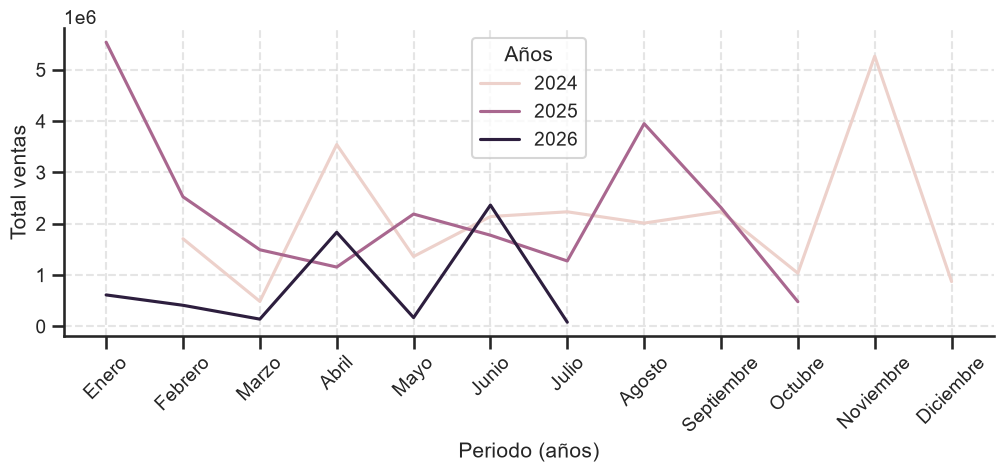

In [76]:
grafico = Graph()
grafico.g_lineplot_tiempo(resumen_ventas_empleados_tiempo, "MES_VENTA", "MES_VENTA", "total_vendido", "ANIO_VENTA")

In [86]:
resumen_ventas_empleados = df_ventas_empleados.groupby(['RESPONSABLE_VENTA','GENERO']).agg(
    estudiantes = ('NUMERO_DE_IDENTIFICACION', 'count'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=('estudiantes'), ascending=False)

resumen_ventas_empleados

,RESPONSABLE_VENTA,GENERO,estudiantes,total_vendido
24,Yurani Daniela Goyes Mora,Femenino,750,21433600.00
25,Yurani Daniela Goyes Mora,Masculino,195,6260000.00
6,Lucio Francisco Rosero Muñoz,Femenino,168,3906999.00
9,Luis Olivares Pinta Lopez,Femenino,154,4452000.00
8,Lucio Francisco Rosero Muñoz,UNKNOWN,146,2358333.15
7,Lucio Francisco Rosero Muñoz,Masculino,81,2148999.00
15,Nicolas Rosero Patiño,Femenino,57,1833000.00
26,Yurani Daniela Goyes Mora,UNKNOWN,34,932000.00
10,Luis Olivares Pinta Lopez,Masculino,34,1203000.00
21,Sebastian Rosero Patiño,Femenino,33,1056000.00


### b. Ventas por Contratos

In [77]:
df_ventas_contrato = df_fv.loc[df_fv['RESPONSABLE_VENTA'].isin(contratos)]

df_ventas_contrato['RESPONSABLE_VENTA'].value_counts()

RESPONSABLE_VENTA
Proinsalud         1250
Ipiales             344
H. San Pedro        101
H. Divino Niño       84
UNKNOWN              64
Fatima               52
Tangua               51
Avanti               37
Corposalud           33
Formedical           24
Espacio Publico      23
Peñol                14
Pupiales             13
Pasto Salud          11
Apolo´S Gym           8
Palermo Imagen        8
Provired              7
Chino Tumaco          4
Fundonar              3
Divino Niño           2
Hosdenar              1
Obsequio              1
Name: count, dtype: int64

In [78]:
resumen_ventas_contrato_tiempo = df_ventas_contrato.groupby(['ANIO_VENTA', 'MES_VENTA']).agg(
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()

In [93]:
resumen_ventas_contrato_tiempo['total_vendido'].mean()

np.float64(2746498.476190476)

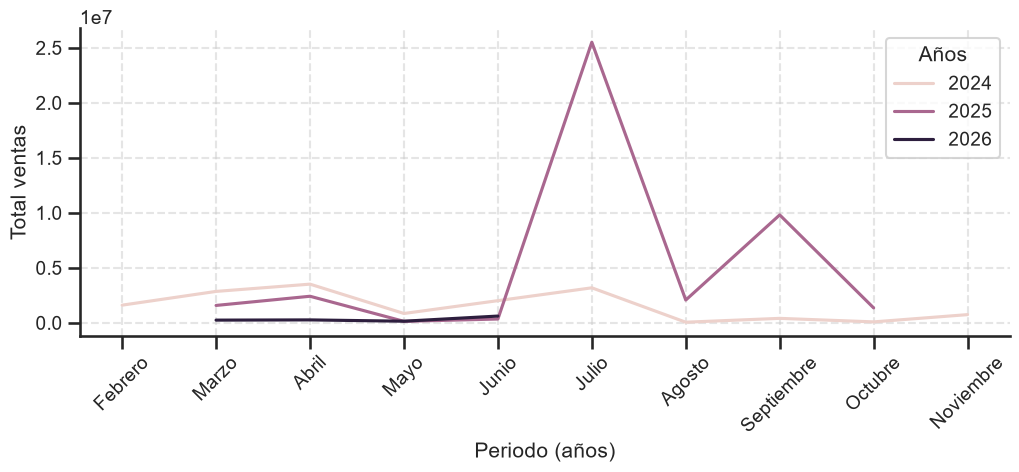

In [79]:
grafico.g_lineplot_tiempo(resumen_ventas_contrato_tiempo, "MES_VENTA", "MES_VENTA", "total_vendido", "ANIO_VENTA")

### c. Ventas por CCS Pasto

In [111]:
df_ventas_ccs = df_fv.loc[df_fv['RESPONSABLE_VENTA'].isin(ccs)]

df_ventas_ccs['RESPONSABLE_VENTA'].value_counts()

RESPONSABLE_VENTA
Ccs    3708
Name: count, dtype: int64

In [112]:
resumen_ventas_ccs_tiempo = df_ventas_ccs.groupby(['ANIO_VENTA', 'MES_VENTA']).agg(
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index()
resumen_ventas_ccs_tiempo

,ANIO_VENTA,MES_VENTA,total_vendido
0,2024,Abril,3567300.00
1,2024,Agosto,3874999.00
2,2024,Diciembre,3554000.00
3,2024,Febrero,2953000.00
4,2024,Julio,3185000.00
5,2024,Junio,3697900.00
6,2024,Marzo,2184000.00
7,2024,Mayo,3091000.00
8,2024,Noviembre,2108000.00
9,2024,Octubre,3244000.00


In [113]:
resumen_ventas_ccs_tiempo['total_vendido'].mean()

np.float64(5283330.037692308)

In [114]:
resumen_ventas_ccs = df_ventas_ccs.groupby(['RESPONSABLE_VENTA','GENERO']).agg(
    estudiantes = ('NUMERO_DE_IDENTIFICACION', 'count'),
    total_vendido = ('PRECIO_NETO', 'sum')
).reset_index().sort_values(by=('estudiantes'), ascending=False)

resumen_ventas_ccs

,RESPONSABLE_VENTA,GENERO,estudiantes,total_vendido
0,Ccs,Femenino,1909,77357193.98
2,Ccs,UNKNOWN,1013,29036900.00
1,Ccs,Masculino,786,30972487.00


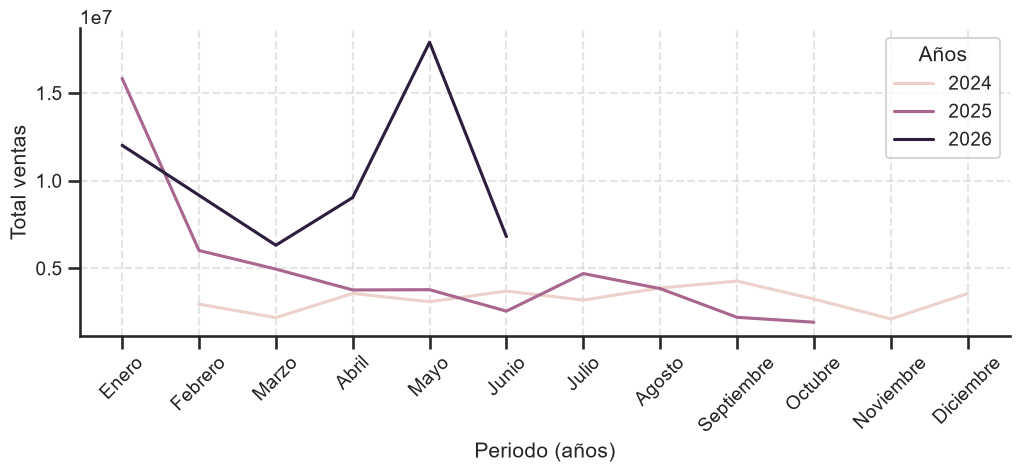

In [115]:
grafico.g_lineplot_tiempo(resumen_ventas_ccs_tiempo, "MES_VENTA", "MES_VENTA", "total_vendido", "ANIO_VENTA")

In [116]:
df_fv_genero = df_fv.loc[df_fv['GENERO'] != 'UNKNOWN']

In [117]:
(df_fv_genero['GENERO']=='Femenino').sum() / df_fv_genero['GENERO'].count()

np.float64(0.7220403239703601)

In [118]:
(df_fv_genero['GENERO']=='Masculino').sum() / df_fv_genero['GENERO'].count()

np.float64(0.27795967602963984)

In [119]:
(df_fv_genero['GENERO']=='UNKNOWN').sum() / df_fv_genero['GENERO'].count()

np.float64(0.0)

#### ¿Qué variables parecen influir más en las ventas?

Los factores que se observa mas afectan las ventas son:

1. los contratos, son los que mayor variacion en ventas por mes dan a CCS Pasto, brindando asi una mayor ganancia eventual por mes en promedio mensual de    $ 2,700,000 COP,

2. las ventas en la sede de CCS pasto tienden a  un incremento en todos los años de operacion en el mes de Enero, para luego estabilizarce en ventas mas frecuentes con un promedio mensual de $ 5,200,000 COP,

3. los vendedores aportan ingresos de forma variable continua durante todo el año, con un promedio de venta por mes de $ 1,800,000 COP

4. Otro factor que influye en las ventas es que cerca del 72% del total de cleintes son mujeres frente a un 28% de clientes hombres

5. El mes de Enero brinda historicamente un incremento en ventas para CCS sede Pasto y para sus vendedores